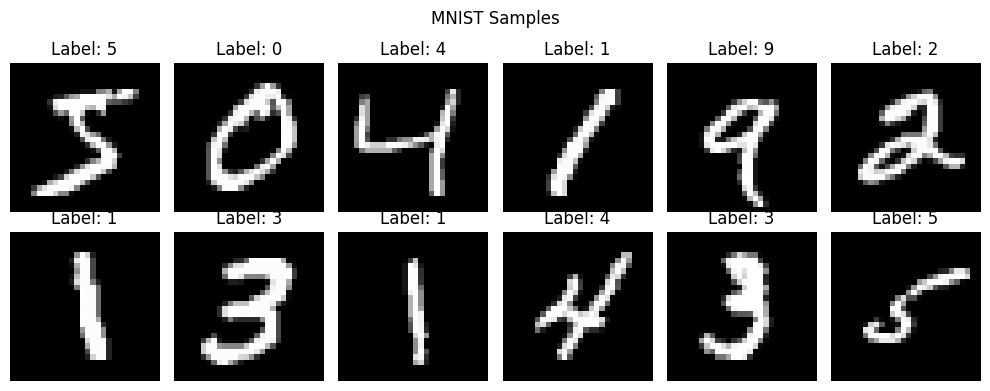

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model

# Load data
(x_train, y_train), _ = mnist.load_data()

# Display first 12 images
plt.figure(figsize=(10, 4))
for i in range(12):
    plt.subplot(2, 6, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.suptitle("MNIST Samples")
plt.tight_layout()
plt.show()

In [6]:
# === 1. Load & Prepare MNIST Data === #
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255
x_test = x_test.reshape(-1, 28, 28, 1).astype('float32') / 255
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

# === 2. Define CNN Model === #
def build_model():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1), name='conv1'),
        layers.MaxPooling2D(2,2),
        layers.Conv2D(64, (3,3), activation='relu', name='conv2'),
        layers.MaxPooling2D(2,2),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# === 3. Train Without Augmentation === #
model_plain = build_model()
history_plain = model_plain.fit(x_train, y_train_cat, epochs=5, batch_size=64,
                                validation_data=(x_test, y_test_cat), verbose=2)

# === 4. Train With Data Augmentation === #
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)
datagen.fit(x_train)

model_aug = build_model()
history_aug = model_aug.fit(datagen.flow(x_train, y_train_cat, batch_size=64),
                            epochs=5, validation_data=(x_test, y_test_cat), verbose=2)

Epoch 1/5


C:\Users\Madhu\anaconda3\envs\FDS\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


938/938 - 7s - 7ms/step - accuracy: 0.9488 - loss: 0.1718 - val_accuracy: 0.9684 - val_loss: 0.0917
Epoch 2/5
938/938 - 6s - 7ms/step - accuracy: 0.9832 - loss: 0.0531 - val_accuracy: 0.9864 - val_loss: 0.0398
Epoch 3/5
938/938 - 6s - 6ms/step - accuracy: 0.9886 - loss: 0.0376 - val_accuracy: 0.9870 - val_loss: 0.0366
Epoch 4/5
938/938 - 5s - 6ms/step - accuracy: 0.9915 - loss: 0.0273 - val_accuracy: 0.9876 - val_loss: 0.0405
Epoch 5/5
938/938 - 5s - 6ms/step - accuracy: 0.9927 - loss: 0.0226 - val_accuracy: 0.9903 - val_loss: 0.0303
Epoch 1/5


C:\Users\Madhu\anaconda3\envs\FDS\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


938/938 - 11s - 11ms/step - accuracy: 0.8973 - loss: 0.3290 - val_accuracy: 0.9847 - val_loss: 0.0474
Epoch 2/5
938/938 - 10s - 11ms/step - accuracy: 0.9652 - loss: 0.1142 - val_accuracy: 0.9845 - val_loss: 0.0469
Epoch 3/5
938/938 - 10s - 11ms/step - accuracy: 0.9748 - loss: 0.0824 - val_accuracy: 0.9904 - val_loss: 0.0292
Epoch 4/5
938/938 - 12s - 13ms/step - accuracy: 0.9780 - loss: 0.0691 - val_accuracy: 0.9898 - val_loss: 0.0294
Epoch 5/5
938/938 - 12s - 12ms/step - accuracy: 0.9818 - loss: 0.0596 - val_accuracy: 0.9917 - val_loss: 0.0242


In [7]:
# Extract metrics from both training histories
plain_metrics = pd.DataFrame(history_plain.history)
aug_metrics = pd.DataFrame(history_aug.history)

# Combine into a single DataFrame
results = pd.DataFrame({
    "Epoch": range(1, len(plain_metrics) + 1),
    "Plain_Train_Acc": plain_metrics['accuracy'],
    "Plain_Val_Acc": plain_metrics['val_accuracy'],
    "Plain_Train_Loss": plain_metrics['loss'],
    "Plain_Val_Loss": plain_metrics['val_loss'],
    "Aug_Train_Acc": aug_metrics['accuracy'],
    "Aug_Val_Acc": aug_metrics['val_accuracy'],
    "Aug_Train_Loss": aug_metrics['loss'],
    "Aug_Val_Loss": aug_metrics['val_loss'],
})

# Display nicely rounded results
pd.set_option('display.precision', 4)
print("\n📈 Per-Epoch Comparison Table:\n")
print(results)


📈 Per-Epoch Comparison Table:

   Epoch  Plain_Train_Acc  Plain_Val_Acc  Plain_Train_Loss  Plain_Val_Loss  \
0      1           0.9488         0.9684            0.1718          0.0917   
1      2           0.9832         0.9864            0.0531          0.0398   
2      3           0.9886         0.9870            0.0376          0.0366   
3      4           0.9915         0.9876            0.0273          0.0405   
4      5           0.9927         0.9903            0.0226          0.0303   

   Aug_Train_Acc  Aug_Val_Acc  Aug_Train_Loss  Aug_Val_Loss  
0         0.8973       0.9847          0.3290        0.0474  
1         0.9652       0.9845          0.1142        0.0469  
2         0.9748       0.9904          0.0824        0.0292  
3         0.9780       0.9898          0.0691        0.0294  
4         0.9818       0.9917          0.0596        0.0242  


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step  

--- Classification Report (No Augmentation) ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      1.00      1.00      1135
           2       1.00      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.98      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.98      0.99      0.99      1028
           8       1.00      0.98      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



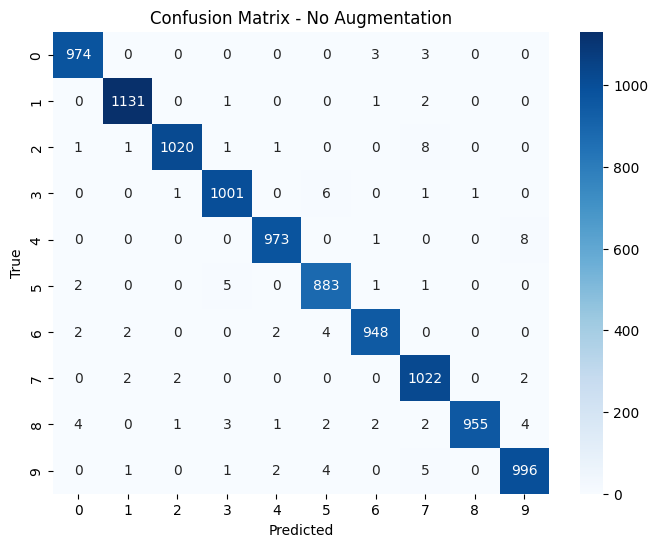

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step  

--- Classification Report (With Augmentation) ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      1.00      0.99      1010
           4       0.99      1.00      0.99       982
           5       0.99      1.00      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       1.00      0.97      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



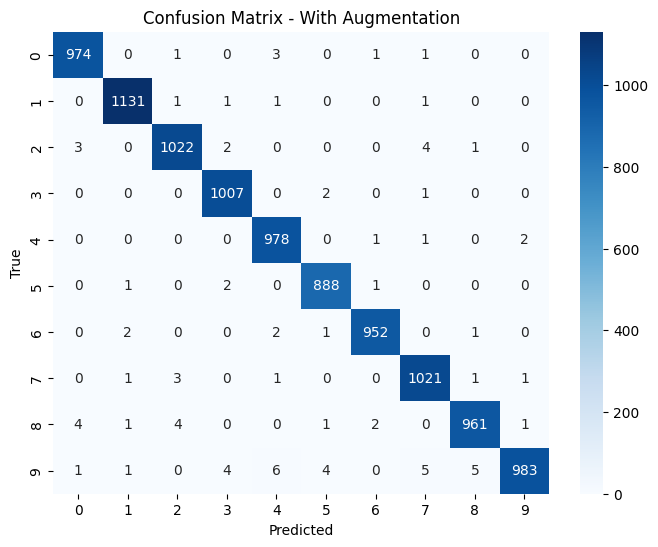

In [8]:
# === 5. Evaluation: Confusion Matrix & Report === #
def evaluate_and_plot(model, x_test, y_test, title):
    y_pred_probs = model.predict(x_test)
    y_pred = np.argmax(y_pred_probs, axis=1)

    print(f"\n--- Classification Report ({title}) ---")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {title}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

evaluate_and_plot(model_plain, x_test, y_test, "No Augmentation")
evaluate_and_plot(model_aug, x_test, y_test, "With Augmentation")

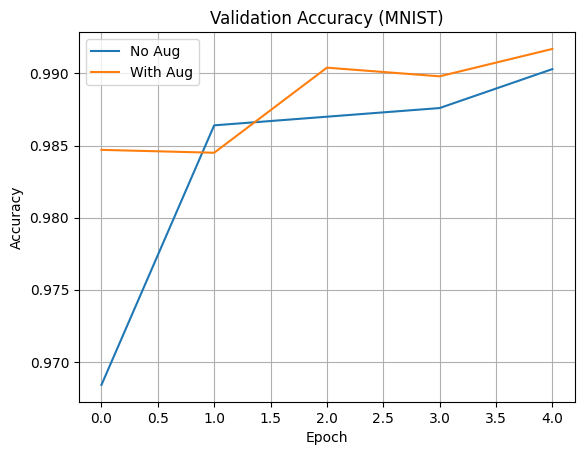

In [9]:
# === 6. Plot Accuracy Curve === #
plt.plot(history_plain.history['val_accuracy'], label='No Aug')
plt.plot(history_aug.history['val_accuracy'], label='With Aug')
plt.title("Validation Accuracy (MNIST)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [4]:
print(x_train.shape)  # → (60000, 28, 28)
print(x_test.shape)   # → (10000, 28, 28)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [5]:
print(x_train[0])

[[[0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]]

 [[0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]]

 [[0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0. 